In [ ]:
!pip install torchinfo

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
import torchinfo
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score


# Positional Encoding class
class PositionalEncoding(nn.Module):
    def __init__(self, hidden_dim, max_len=15):
        super(PositionalEncoding, self).__init__()
        self.hidden_dim = hidden_dim

        # Create positional encoding matrix
        pe = torch.zeros(max_len, hidden_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, hidden_dim, 2).float() * (-math.log(10000.0) / hidden_dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer so it doesn't get updated by gradients
        self.pe = pe.unsqueeze(0)  # Shape: (1, max_len, hidden_dim)

    def forward(self, x):
        # Ensure positional encoding is on the same device as x
        self.pe = self.pe.to(x.device)

        # Add positional encoding to the input (broadcasting across the batch)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

In [ ]:
import torch.nn as nn
import torch

# VideoEmotionTransformer class
class VideoEmotionTransformer(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads, num_layers, num_classes, dropout, max_len):
        super(VideoEmotionTransformer, self).__init__()

        self.fc_in = nn.Linear(input_dim, hidden_dim)

        # Positional Encoding
        self.positional_encoding = PositionalEncoding(hidden_dim, max_len)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dropout = dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        self.fc_out = nn.Linear(hidden_dim, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x, mask=None, extract_embeddings=False):
        # Project input to hidden dimension
        x = self.fc_in(x)  # Shape: (batch_size, num_frames, hidden_dim)

        # Apply positional encoding
        x = self.positional_encoding(x)  # Shape: (batch_size, num_frames, hidden_dim)

        # Permute for transformer input (transformers expect (sequence_length, batch_size, feature_dim))
        x = x.permute(1, 0, 2)  # Shape: (num_frames, batch_size, hidden_dim)

        # Pass through transformer encoder
        output = self.transformer_encoder(x, src_key_padding_mask=mask)

        # Permute back to (batch_size, num_frames, hidden_dim)
        output = output.permute(1, 0, 2)

        if extract_embeddings:
            return output.mean(dim=1)  # Return embeddings for extraction

        output = output.mean(dim=1)  # Average over the time dimension (num_frames) for final classification
        # Pass through the output layer
        output = self.fc_out(output)


        return output

In [ ]:
# Mask generation for padded sequences
def generate_padding_mask(batch, pad_token=0):
    mask = (batch.sum(dim=-1) == pad_token)  # Shape: (batch_size, num_frames)
    return mask  # True for padded frames


# Data Processing
def preprocess_data(csv_path, max_len=15, input_dim=512):
    # Load the CSV data
    data = pd.read_csv(csv_path)

    # 2. Cleanup Labels (Merges 's' and 'S', removes 'U')
    data['Label'] = data['Label'].str.strip().str.upper()
    core_emotions = ['A', 'H', 'L', 'N', 'S']
    data = data[data[ 'Label' ].isin(core_emotions)]

    # Assume 'Counter' column indicates frames and group the features
    feature_columns = [col for col in data.columns if col.startswith('E_')] # Changed 'Embedding' to 'E_'

    # Group by 'Counter' to get the frames of each video
    grouped = data.groupby('Counter')
    video_features, video_labels, video_links = [], [], []

    for counter, group in grouped:
        features = group[feature_columns].values  # Features for the frames
        label = group['Label'].iloc[0]  # Assuming all frames of a video share the same label

        raw_link = group['Link'].iloc[0]
        # Apply padding if the number of frames < max_len
        if len(features) < max_len:
            pad_length = max_len - len(features)
            padding = torch.zeros((pad_length, input_dim))  # Padding with zeros
            features = torch.cat((torch.tensor(features), padding), dim=0)
        else:
            features = torch.tensor(features[:max_len])  # Truncate to max_len

        video_features.append(features)
        video_labels.append(label)
        video_links.append(raw_link)

    # Convert lists to tensors
    video_features = torch.stack(video_features)

    # Convert video labels into a tensor (after label encoding)
    label_encoder = LabelEncoder()
    video_labels = torch.tensor(label_encoder.fit_transform(video_labels))

    # Print the mapping of original labels to numeric values
    label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
    print("Label encoding mapping:")
    for label, numeric in label_mapping.items():
        print(f"{label}: {numeric}")

    return video_features, video_labels, video_links

In [ ]:
from imblearn.over_sampling import SMOTE


# Function to apply SMOTE and prepare DataLoaders
def prepare_data_loaders(video_features, video_labels, batch_size, test_size=0.2):
    # Reshape the video features to 2D (samples, frames * features) for SMOTE
    num_samples, num_frames, num_features = video_features.shape
    reshaped_features = video_features.view(num_samples, -1)  # (samples, frames * features)

    # Apply SMOTE to balance the dataset
    smote = SMOTE(random_state=42)
    reshaped_features_np = reshaped_features.cpu().numpy()
    video_labels_np = video_labels.cpu().numpy()
    X_resampled, y_resampled = smote.fit_resample(reshaped_features_np, video_labels_np)

    # Reshape the resampled features back to 3D (samples, frames, features)
    X_resampled_3d = torch.tensor(X_resampled).view(-1, num_frames, num_features)
    y_resampled = torch.tensor(y_resampled)

    # Split the resampled data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_resampled_3d, y_resampled, test_size=test_size, random_state=42)
    # print(X_train.shape)
    # print(y_train.shape)
    # print(X_test.shape)
    # Create datasets
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [ ]:
# Training Loop
def train_model(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for video_batch, labels in data_loader:
        video_batch, labels = video_batch.to(device).float(), labels.to(device).long()

        # Ensure video_batch is in the correct dtype (float32)
        #video_batch = video_batch.float()  # Convert to torch.float32

        # Generate padding mask
        padding_mask = generate_padding_mask(video_batch).to(device)

        # Forward pass
        outputs = model(video_batch, mask=padding_mask)

        # Calculate loss
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return model, avg_loss, accuracy

In [ ]:
def test_model(model, data_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():  # Disable gradient computation for testing
        for video_batch, labels in data_loader:
            video_batch = video_batch.to(device).float()
            labels = labels.to(device).long()

            # Generate padding mask (if applicable)
            padding_mask = generate_padding_mask(video_batch).to(device)
            #print(padding_mask)

            # Forward pass
            outputs = model(video_batch, mask=padding_mask)

            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)


    avg_loss = total_loss / len(data_loader)
    accuracy = (correct_predictions / total_samples)

    return avg_loss, accuracy

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.model_selection import StratifiedKFold


# Updated cross-validation function
def k_fold_cross_validation(model_class, video_features, video_labels, num_folds, batch_size, num_epochs, learning_rate, device):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    fold_results = []  # To store results for each fold
    # all_embeddings = []  # To store embeddings for all folds
    all_predicted = []
    all_targets = []
    trained_model = None

    for fold, (train_idx, test_idx) in enumerate(skf.split(video_features, video_labels)):
        print(f"Fold {fold + 1}/{num_folds}")

        # Split data into training and testing for this fold
        X_train, X_test = video_features[train_idx], video_features[test_idx]
        y_train, y_test = video_labels[train_idx], video_labels[test_idx]

        # Apply SMOTE and prepare DataLoaders
        train_loader, test_loader = prepare_data_loaders(X_train, y_train, batch_size)

        model_fold = model_class.to(device)

        model_fold = VideoEmotionTransformer(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            num_layers=num_layers,
            num_classes=num_classes,
            dropout=dropout,
            max_len=max_len
       ).to(device)


        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model_fold.parameters(), lr=learning_rate)

        # Training and testing loop for the fold
        for epoch in range(num_epochs):
            model_fold, avg_train_loss, accuracy_train = train_model(model_fold, train_loader, criterion, optimizer, device)
            avg_test_loss, accuracy_test = test_model(model_fold, test_loader, criterion, device)

            print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, "
                  f"Train Accuracy: {accuracy_train * 100:.2f}%, "
                  f"Test Loss: {avg_test_loss:.4f}, "
                  f"Test Accuracy: {accuracy_test * 100:.2f}%, ")

        trained_model = model_fold

        # # Collect embeddings and true labels for this fold
        # embeddings, targets = get_embeddings(model_fold, test_loader, device)
        # all_embeddings.extend(embeddings)
        # all_targets.extend(targets)

        # Collect predictions and true labels for this fold
        predicted, targets = get_predictions(model_fold, test_loader, device)
        all_predicted.extend(predicted)
        all_targets.extend(targets)

        # Store results for this fold
        fold_results.append({
            'fold': fold + 1,
            'train_loss': avg_train_loss,
            'train_accuracy': accuracy_train,
            'test_loss': avg_test_loss,
            'test_accuracy': accuracy_test
        })

    #After cross-validation, calculate and print average results across all folds
    avg_train_loss = np.mean([res['train_loss'] for res in fold_results])
    avg_train_accuracy = np.mean([res['train_accuracy'] for res in fold_results])
    avg_test_loss = np.mean([res['test_loss'] for res in fold_results])
    avg_test_accuracy = np.mean([res['test_accuracy'] for res in fold_results])

    print("\nCross-validation results:")
    print(f"Average Train Loss: {avg_train_loss:.4f}")
    print(f"Average Train Accuracy: {avg_train_accuracy * 100:.2f}%")
    print(f"Average Test Loss: {avg_test_loss:.4f}")
    print(f"Average Test Accuracy: {avg_test_accuracy * 100:.2f}%")

   # Calculate and print performance metrics for the whole cross-validation process
    accuracy = accuracy_score(all_targets, all_predicted)
    f1 = f1_score(all_targets, all_predicted, average='weighted')
    report = classification_report(all_targets, all_predicted)
    conf_matrix = confusion_matrix(all_targets, all_predicted)

    print(f"\nFinal Accuracy: {accuracy:.4f}")
    print(f"Final F1 Score: {f1:.4f}")
    print("Classification Report:\n", report)

    # Plot confusion matrix
    label_encoder = LabelEncoder()
    label_encoder.fit(video_labels)
    class_labels = label_encoder.classes_

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return trained_model #, fold_results

#Helper function to get predictions from the model
def get_predictions(model, test_loader, device):
    model.eval()
    all_predicted = []
    all_targets = []

    with torch.no_grad():
        for video_batch, labels in test_loader:
            # Move data to device and ensure correct dtype (float32)
            video_batch = video_batch.to(device).float()  # Convert to float32
            labels = labels.to(device)

            # Generate padding mask if needed
            padding_mask = generate_padding_mask(video_batch).to(device)

            # Get the model outputs
            outputs = model(video_batch, mask=padding_mask)

            # Get the predicted class
            _, predicted = torch.max(outputs, 1)
            all_predicted.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    return all_predicted, all_targets

In [ ]:
# Define model parameters
batch_size = 16
num_epochs = 100
num_folds = 5

input_dim = 512  # Adjust according to your input features
dropout = 0.3
hidden_dim = 256  # Dimension for the hidden layers 256
num_heads = 2     # Number of heads in the transformer 2
num_layers = 4   # Number of transformer layers 2
num_classes = 5   # Number of emotion classes
max_len = 15      # Maximum sequence length (video frames)
lr = 0.0001         # Learning rate #0.0001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Preprocess data
import pandas as pd
video_features, video_labels, video_links = preprocess_data("/content/drive/MyDrive/Embedding /videos_face_embeddings_final.csv", max_len=max_len, input_dim=input_dim)

Label encoding mapping:
A: 0
H: 1
L: 2
N: 3
S: 4


In [ ]:
video_features.shape

torch.Size([8575, 15, 512])

In [ ]:
from torchinfo import summary
import torchinfo



# Model, loss function, optimizer
model = VideoEmotionTransformer(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout = dropout,
    num_heads=num_heads,
    max_len=max_len
).to(device)


# Print model summary
torchinfo.summary(model, input_size=(batch_size, max_len, input_dim))

/tmp/ipykernel_7456/1017127624.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)


Layer (type:depth-idx)                        Output Shape              Param #
VideoEmotionTransformer                       [16, 5]                   --
├─Linear: 1-1                                 [16, 15, 256]             131,328
├─PositionalEncoding: 1-2                     [16, 15, 256]             --
├─TransformerEncoder: 1-3                     [15, 16, 256]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [15, 16, 256]             1,315,072
│    │    └─TransformerEncoderLayer: 3-2      [15, 16, 256]             1,315,072
│    │    └─TransformerEncoderLayer: 3-3      [15, 16, 256]             1,315,072
│    │    └─TransformerEncoderLayer: 3-4      [15, 16, 256]             1,315,072
├─Linear: 1-4                                 [16, 5]                   1,285
Total params: 5,392,901
Trainable params: 5,392,901
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 65.24
Input size (MB): 

Fold 1/5


/tmp/ipykernel_7456/1017127624.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)


Epoch [1/100], Train Loss: 1.6202, Train Accuracy: 23.30%, Test Loss: 1.5728, Test Accuracy: 26.51%, 
Epoch [2/100], Train Loss: 1.4881, Train Accuracy: 35.35%, Test Loss: 1.4610, Test Accuracy: 37.98%, 
Epoch [3/100], Train Loss: 1.3992, Train Accuracy: 40.84%, Test Loss: 1.3871, Test Accuracy: 42.09%, 
Epoch [4/100], Train Loss: 1.3575, Train Accuracy: 43.64%, Test Loss: 1.3629, Test Accuracy: 42.39%, 
Epoch [5/100], Train Loss: 1.3331, Train Accuracy: 44.06%, Test Loss: 1.3874, Test Accuracy: 43.92%, 
Epoch [6/100], Train Loss: 1.3150, Train Accuracy: 45.75%, Test Loss: 1.3533, Test Accuracy: 43.97%, 
Epoch [7/100], Train Loss: 1.3027, Train Accuracy: 46.05%, Test Loss: 1.3374, Test Accuracy: 45.50%, 
Epoch [8/100], Train Loss: 1.2858, Train Accuracy: 47.25%, Test Loss: 1.3851, Test Accuracy: 45.27%, 
Epoch [9/100], Train Loss: 1.2747, Train Accuracy: 47.91%, Test Loss: 1.3428, Test Accuracy: 45.50%, 
Epoch [10/100], Train Loss: 1.2582, Train Accuracy: 48.53%, Test Loss: 1.3147, Tes

/tmp/ipykernel_7456/1017127624.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)


Epoch [1/100], Train Loss: 1.6082, Train Accuracy: 24.76%, Test Loss: 1.5321, Test Accuracy: 31.75%, 
Epoch [2/100], Train Loss: 1.4486, Train Accuracy: 38.10%, Test Loss: 1.4668, Test Accuracy: 40.74%, 
Epoch [3/100], Train Loss: 1.3774, Train Accuracy: 41.75%, Test Loss: 1.3800, Test Accuracy: 43.97%, 
Epoch [4/100], Train Loss: 1.3407, Train Accuracy: 43.83%, Test Loss: 1.3252, Test Accuracy: 46.50%, 
Epoch [5/100], Train Loss: 1.3243, Train Accuracy: 45.31%, Test Loss: 1.3072, Test Accuracy: 47.68%, 
Epoch [6/100], Train Loss: 1.3062, Train Accuracy: 45.68%, Test Loss: 1.2965, Test Accuracy: 49.38%, 
Epoch [7/100], Train Loss: 1.2853, Train Accuracy: 46.88%, Test Loss: 1.2917, Test Accuracy: 48.27%, 
Epoch [8/100], Train Loss: 1.2779, Train Accuracy: 47.81%, Test Loss: 1.3098, Test Accuracy: 49.85%, 
Epoch [9/100], Train Loss: 1.2503, Train Accuracy: 49.15%, Test Loss: 1.2986, Test Accuracy: 49.03%, 
Epoch [10/100], Train Loss: 1.2379, Train Accuracy: 49.78%, Test Loss: 1.3182, Tes

...

Epoch [1/100], Train Loss: 1.6150, Train Accuracy: 23.75%, Test Loss: 1.5416, Test Accuracy: 30.79%, 
Epoch [2/100], Train Loss: 1.4983, Train Accuracy: 33.73%, Test Loss: 1.3922, Test Accuracy: 40.48%, 
Epoch [3/100], Train Loss: 1.3863, Train Accuracy: 40.75%, Test Loss: 1.3907, Test Accuracy: 41.42%, 
Epoch [4/100], Train Loss: 1.3489, Train Accuracy: 42.83%, Test Loss: 1.3640, Test Accuracy: 43.01%, 
Epoch [5/100], Train Loss: 1.3270, Train Accuracy: 44.43%, Test Loss: 1.3566, Test Accuracy: 43.24%, 
Epoch [6/100], Train Loss: 1.3128, Train Accuracy: 45.30%, Test Loss: 1.3574, Test Accuracy: 42.95%, 
Epoch [7/100], Train Loss: 1.2929, Train Accuracy: 46.67%, Test Loss: 1.3406, Test Accuracy: 44.95%, 
Epoch [8/100], Train Loss: 1.2739, Train Accuracy: 47.65%, Test Loss: 1.3087, Test Accuracy: 47.12%, 
Epoch [9/100], Train Loss: 1.2618, Train Accuracy: 47.99%, Test Loss: 1.3041, Test Accuracy: 46.18%, 
Epoch [10/100], Train Loss: 1.2503, Train Accuracy: 48.91%, Test Loss: 1.3456, Tes

/tmp/ipykernel_7456/1017127624.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)


Epoch [1/100], Train Loss: 1.6209, Train Accuracy: 23.41%, Test Loss: 1.5298, Test Accuracy: 33.37%, 
Epoch [2/100], Train Loss: 1.4619, Train Accuracy: 36.41%, Test Loss: 1.5499, Test Accuracy: 32.08%, 
Epoch [3/100], Train Loss: 1.3855, Train Accuracy: 41.00%, Test Loss: 1.4116, Test Accuracy: 42.13%, 
Epoch [4/100], Train Loss: 1.3515, Train Accuracy: 42.70%, Test Loss: 1.3641, Test Accuracy: 44.36%, 
Epoch [5/100], Train Loss: 1.3264, Train Accuracy: 44.62%, Test Loss: 1.3525, Test Accuracy: 44.65%, 
Epoch [6/100], Train Loss: 1.3091, Train Accuracy: 45.01%, Test Loss: 1.3502, Test Accuracy: 45.01%, 
Epoch [7/100], Train Loss: 1.2967, Train Accuracy: 45.96%, Test Loss: 1.3798, Test Accuracy: 42.95%, 
Epoch [8/100], Train Loss: 1.2870, Train Accuracy: 46.77%, Test Loss: 1.4500, Test Accuracy: 41.42%, 
Epoch [9/100], Train Loss: 1.2758, Train Accuracy: 47.00%, Test Loss: 1.3399, Test Accuracy: 46.06%, 
Epoch [10/100], Train Loss: 1.2557, Train Accuracy: 48.27%, Test Loss: 1.3472, Tes

/tmp/ipykernel_7456/1017127624.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)


Epoch [1/100], Train Loss: 1.6271, Train Accuracy: 22.66%, Test Loss: 1.5862, Test Accuracy: 23.15%, 
Epoch [2/100], Train Loss: 1.4937, Train Accuracy: 34.78%, Test Loss: 1.4150, Test Accuracy: 41.72%, 
Epoch [3/100], Train Loss: 1.3961, Train Accuracy: 40.85%, Test Loss: 1.4434, Test Accuracy: 41.95%, 
Epoch [4/100], Train Loss: 1.3525, Train Accuracy: 42.69%, Test Loss: 1.4272, Test Accuracy: 43.01%, 
Epoch [5/100], Train Loss: 1.3330, Train Accuracy: 45.01%, Test Loss: 1.3904, Test Accuracy: 42.36%, 
Epoch [6/100], Train Loss: 1.3135, Train Accuracy: 45.11%, Test Loss: 1.3699, Test Accuracy: 44.71%, 
Epoch [7/100], Train Loss: 1.3041, Train Accuracy: 46.78%, Test Loss: 1.3199, Test Accuracy: 46.30%, 
Epoch [8/100], Train Loss: 1.2980, Train Accuracy: 46.97%, Test Loss: 1.3707, Test Accuracy: 42.89%, 
Epoch [9/100], Train Loss: 1.2759, Train Accuracy: 48.34%, Test Loss: 1.4006, Test Accuracy: 43.65%, 
Epoch [10/100], Train Loss: 1.2651, Train Accuracy: 48.37%, Test Loss: 1.4409, Tes

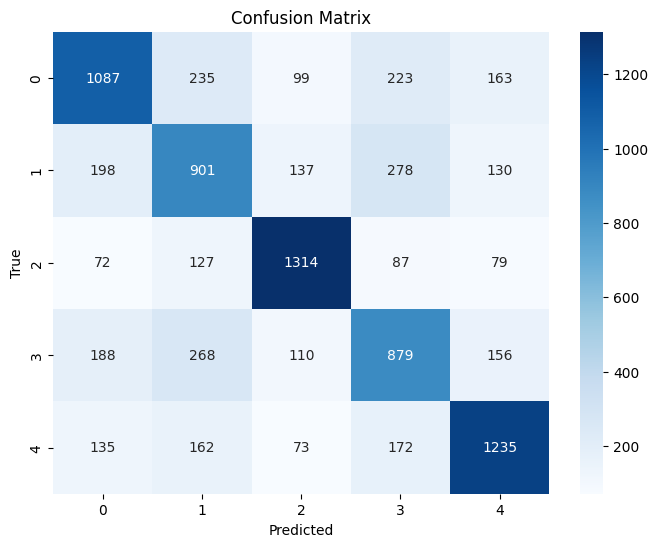

In [ ]:
# K-fold cross-validation
model_trained = k_fold_cross_validation(model, video_features, video_labels, num_folds=num_folds, batch_size=batch_size, num_epochs=num_epochs, learning_rate=lr, device=device)

In [ ]:
model_trained = model.to(device).float()  # Ensure model is in Float
model_trained.eval()  # Set the model to evaluation mode

VideoEmotionTransformer(
  (fc_in): Linear(in_features=512, out_features=256, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=2048, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=256, out_features=5, bias=True)
  (softmax): Softmax(dim=1)
)

In [ ]:
# Preprocess data
video_features, video_labels, video_links = preprocess_data("/content/drive/MyDrive/Embedding /videos_face_embeddings_final.csv", max_len=max_len, input_dim=input_dim)

Label encoding mapping:
A: 0
H: 1
L: 2
N: 3
S: 4


In [ ]:
video_features.shape

torch.Size([8575, 15, 512])

In [ ]:
# Splitting and DataLoader Preparation
def prepare_data_loaders_emb(video_features, video_labels, batch_size):

    # Create datasets
    train_dataset = TensorDataset(video_features, video_labels)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)


    return train_loader

In [ ]:
# Prepare DataLoaders
data_loader = prepare_data_loaders_emb(video_features, video_labels, batch_size=batch_size)

In [ ]:
all_embeddings = []
all_labels = []

with torch.no_grad():  # No need to compute gradients
    for video_features, labels in data_loader:
        video_features = video_features.to(device).float()  # Convert to Float
        labels = labels.to(device)  # Ensure labels are also on the correct device

        # Extract embeddings
        embeddings = model_trained(video_features, extract_embeddings=True)

        all_embeddings.append(embeddings.cpu().numpy())  # Move to CPU and convert to numpy
        all_labels.append(labels.cpu().numpy())  # Collect labels as well

# Concatenate embeddings and labels across all batches
all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [ ]:
# # Print results
# print("\nFold Results:")
# for result in fold_results:
#     print(result)

print("\nExtracted Embeddings Shape:", all_embeddings.shape)
print("Targets Shape:", all_labels.shape)


Extracted Embeddings Shape: (8575, 256)
Targets Shape: (8575,)


In [ ]:
all_embeddings

array([[ 0.48811787,  0.29156324, -0.22805898, ...,  1.4203769 ,
        -0.13723466, -0.893603  ],
       [ 0.49611482,  0.2624762 , -0.26517224, ...,  1.3777702 ,
        -0.0831949 , -0.8810416 ],
       [ 0.529949  ,  0.35943446, -0.2616255 , ...,  1.3980263 ,
        -0.17039998, -0.80035734],
       ...,
       [ 0.532491  ,  0.23208165, -0.29516557, ...,  1.3779613 ,
        -0.09104788, -0.8026024 ],
       [ 0.5364162 ,  0.22887704, -0.2937767 , ...,  1.3928798 ,
        -0.09249764, -0.8146307 ],
       [ 0.5428176 ,  0.24127737, -0.3172375 , ...,  1.39285   ,
        -0.0907637 , -0.8442604 ]], dtype=float32)

In [ ]:
import pandas as pd
import numpy as np

# Convert embeddings and targets to numpy arrays if they are not already
all_embeddings = np.array(all_embeddings)
all_targets = np.array(all_labels)

# Ensure that embeddings and targets have the same number of samples
assert all_embeddings.shape[0] == all_targets.shape[0], "Mismatch between number of embeddings and targets"

# Convert embeddings to DataFrame
embeddings_df = pd.DataFrame(all_embeddings)

# Add the targets column
embeddings_df['Target'] = all_targets
embeddings_df['Link'] = video_links

# Save the DataFrame to CSV
embeddings_df.to_csv('video_embeddings_transformer.csv', index=False)

print("\nEmbeddings and targets have been saved to 'video_embeddings_transformer.csv'.")


Embeddings and targets have been saved to 'video_embeddings_transformer.csv'.


In [ ]:
df=pd.read_csv("/content/video_embeddings_transformer.csv")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,248,249,250,251,252,253,254,255,Target,Link
0,0.488118,0.291563,-0.228059,0.324996,-0.378176,1.286465,-0.262694,0.380209,0.306930,-2.051331,...,-0.866513,0.204618,0.367024,0.263606,0.314070,1.420377,-0.137235,-0.893603,0,/content/drive/MyDrive/1FPS_video/Anger_39_202...
1,0.496115,0.262476,-0.265172,0.356475,-0.357901,1.234754,-0.310406,0.487503,0.243039,-2.069476,...,-0.895610,0.279921,0.345012,0.337417,0.298739,1.377770,-0.083195,-0.881042,0,/content/drive/MyDrive/1FPS_video/Anger_39_203...
2,0.529949,0.359434,-0.261626,0.385602,-0.287143,1.206998,-0.249627,0.358817,0.249067,-2.008342,...,-0.771444,0.302378,0.252867,0.221831,0.311240,1.398026,-0.170400,-0.800357,0,/content/drive/MyDrive/1FPS_video/Anger_39_220...
3,0.492437,0.294496,-0.250550,0.331929,-0.379569,1.254620,-0.289348,0.383242,0.288548,-2.054823,...,-0.871689,0.226445,0.336996,0.286316,0.296298,1.418116,-0.124903,-0.919688,0,/content/drive/MyDrive/1FPS_video/Anger_39_205...
4,0.538331,0.331588,-0.275240,0.376636,-0.290866,1.207126,-0.254901,0.377727,0.246101,-2.042191,...,-0.796980,0.286336,0.259669,0.243126,0.307899,1.390951,-0.155121,-0.842295,0,/content/drive/MyDrive/1FPS_video/Anger_39_225...


In [ ]:
!cp -r "/content/video_embeddings_transformer.csv" "/content/drive/MyDrive/Embedding /video_embeddings_transformer_1.csv"